In [ ]:
from astropy import units as un, constants as cons
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from matplotlib import pyplot as plt
from astropy.visualization import quantity_support
quantity_support()
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

from cgm_ics.latexify import latexify
from cgm_ics import solve_ode as CF
from cgm_ics import halo_potentials as Halo
from cgm_ics import cooling_functions as Cool

In [2]:
# Set Cosmology
rho_crit = cosmo.critical_density0
rho_mean = cosmo.Om0*rho_crit
delta_c =  18 * np.pi**2 + 82 * (cosmo.Om0 - 1) - 39 * (cosmo.Om0 - 1)**2 # Bryan & Norman 98
mu = 0.62 # mean molecular weight

print(cosmo)

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)


In [3]:
# Helper function for dervied values
def calc_r_vir(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / delta_c / rho_crit, 1/3)
    return r_vir.to('kpc')

def calc_r_200_c(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_crit, 1/3)
    return r_vir.to('kpc')
    
def calc_r_200_m(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_mean, 1/3)
    return r_vir.to('kpc')

def calc_T_vir(M_vir):
    r_vir = calc_r_vir(M_vir)
    vc = np.sqrt(cons.G * M_vir / r_vir)
    temp = mu*cons.m_p*vc**2/cons.k_B/2
    return temp.to('K')

def calc_concentration(M_vir):
    h = cosmo.H0.value/100
    M_ref = 1e12/h * un.Msun
    log_c = 0.905 - 0.101*np.log10(M_vir/M_ref)
    return np.power(10, log_c)

def circular_temp(vc):
    temp = 0.6*mu*cons.m_p*vc**2/cons.k_B
    return temp.to('K')

In [4]:
# Set Halo Parameters
M_vir = 1e11 * un.Msun
r_vir = calc_r_vir(M_vir)
T_vir = calc_T_vir(M_vir)
c_vir = calc_concentration(M_vir) # Concentration parameter
r_200_m = calc_r_200_m(M_vir)
r_200_c = calc_r_200_c(M_vir)
M_gal = 1e10 * un.Msun # Greco et al 2012 for M82
r_gal = 0.015*r_200_c # Kravtsoc 2013 expression for stellar half-mass radius
z_gal = 0.15 * un.kpc # Lim et al 2013 for M82

print(c_vir)
      
print("Halo Mass: ",np.log10(M_vir.value))
print("Virial Radius: ", r_vir)
print("Virial Temperature: ", T_vir)
print("Concentration Parameter: ", c_vir)
print("R200m: ", r_200_m)
print("R200c: ", r_200_c)
print("Disk Mass", M_gal)
print("Disk Scale Radius", r_gal)
print("Disk Scale Height", z_gal)

# Set Halo Potential
nfw = Halo.NFWPotential(M_vir, r_vir, c_vir)
plummer = Halo.PlummerPotential(M_gal, r_gal)
outer = Halo.OuterHaloPotential(rho_mean, r_200_m)
combined = Halo.CombinedPotential(M_vir, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)
miyamoto = Halo.MiyamotoNagaiPotential(M_gal, r_gal, z_gal)

print("NFW Scale Density: ", nfw.rho_s)

10.54718269190388
Halo Mass:  11.0
Virial Radius:  122.40315626626357 kpc
Virial Temperature:  131960.7175211719 K
Concentration Parameter:  10.54718269190388
R200m:  144.76736317842207 kpc
R200c:  97.94126310709676 kpc
Disk Mass 10000000000.0 solMass
Disk Scale Radius 1.4691189466064514 kpc
Disk Scale Height 0.15 kpc
NFW Scale Density:  3320989.038326563 solMass / kpc3


In [5]:
# Set Units
cu_length  = 3.0856775809623245e+21 * un.cm # kpc
cu_mass    = 3.036951775493658e+39 * un. g  # number density 0.1 cm^-3 when box size is 1 kpc
cu_time    = 3.15576e+15  * un.s            # 100 Myr

# Derived Units
cu_velocity = cu_length/cu_time # cm/s
cu_density = cu_mass/cu_length**3 # g/cm**3
cu_energy = cu_mass*cu_velocity**2 # erg
cu_pressure = cu_energy/cu_length**3 # erg/cm**3 or dyne/cm^2
cu_temperature = cu_velocity**2*mu*cons.m_p/cons.k_B # K

print(cu_velocity.to('km/s'))
print(cu_density.to('g/cm3'))
print(cu_temperature.to('K'))

9.777922215131456 km / s
1.0336803493720967e-25 g / cm3
7181.238455976716 K


In [6]:
print("Input Parameters in Code Units")
print(f"r_scale   = {(combined.r_s/cu_length).to('')}")
print(f"rho_scale = {(combined.rho_s/cu_density).to('')}")
print(f"mass_gal  = {(combined.M_gal/cu_mass).to('')}")
print(f"scale_gal = {(combined.a_gal/cu_length).to('')}")
print(f"z_gal     = {(z_gal/cu_length).to('')}")
print(f"r_200     = {(combined.R200/cu_length).to('')}")
print(f"rho_mean  = {(combined.rho_mean/cu_density).to('')}")


Input Parameters in Code Units
r_scale   = 11.605294026167536
rho_scale = 2.1743800590375333
mass_gal  = 6547.387043624801
scale_gal = 1.4691189468583334
z_gal     = 0.15000000002571764
r_200     = 144.7673632032426
rho_mean  = 2.5759499291277927e-05


In [7]:
print(combined.vc(10*un.kpc))
print((combined.vc(10*un.kpc)/cu_velocity).to(''))

93.28970793857599 km / s
9.54085191986995


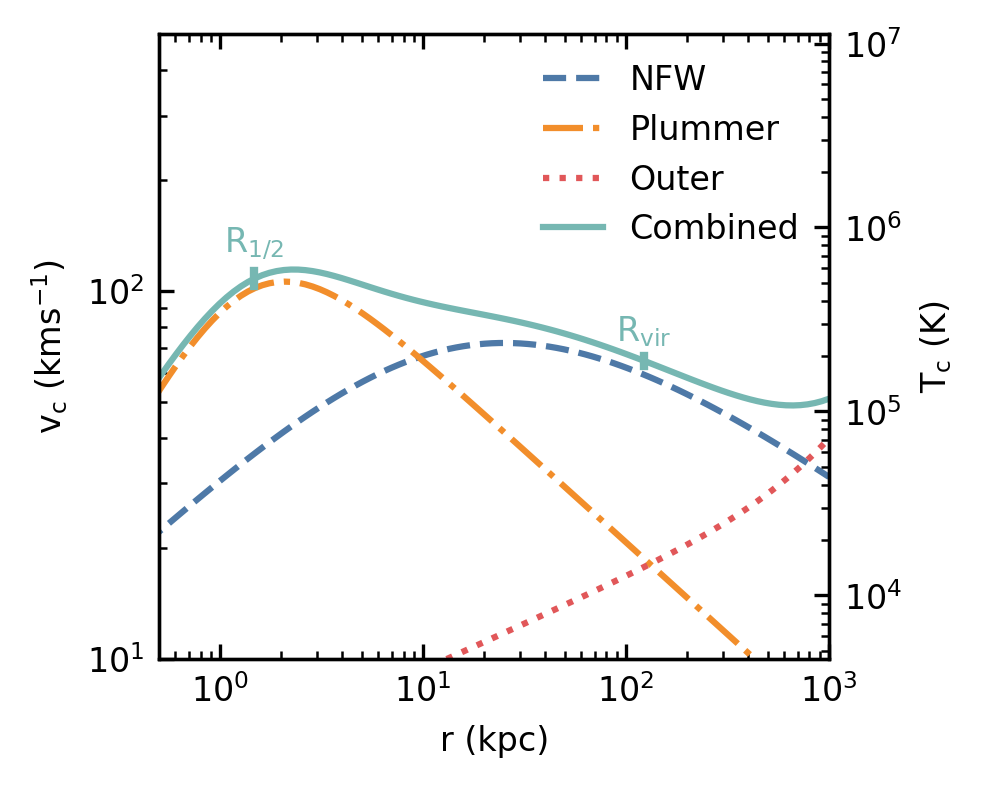

In [35]:
# Plot the circular velocity and its components
rs = np.logspace(-0.5,3,100) * un.kpc

cvs = nfw.vc(rs)
p_cvs = plummer.vc(rs)
o_cvs = outer.vc(rs)
c_cvs = combined.vc(rs)

latexify(columns=1)
plt.figure()
ax=plt.gca()
ax.tick_params(top=True, right=True, which="both", direction='in')
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.5,1000)
plt.ylim(10,500)

plt.plot(rs,cvs,ls='--',label="NFW")
plt.plot(rs,p_cvs,ls='-.',label="Plummer")
plt.plot(rs,o_cvs,ls=':',label="Outer")
plt.plot(rs,c_cvs,ls='-',label="Combined")

tick_length = 2
ticks = [r_vir,r_200_m,r_200_c,r_gal]
tick_labels = [r'R$_{\rm vir}$', r'R$_{\rm 200m}$', r'R$_{\rm 200c}$', r'R$_{\rm 1/2}$']
label_dirs = [-3,1,1,1]

tick_length = 2
plt.plot([r_vir.value,r_vir.value], 
         [combined.vc(r_vir).value - tick_length, combined.vc(r_vir).value + tick_length], 
         color="C3", lw=2)
plt.text(r_vir.value,combined.vc(r_vir).value + tick_length * 2.5, r'R$_{\rm vir}$',
         color="C3", ha='center', va='bottom')

tick_length = 5
plt.plot([r_gal.value,r_gal.value], 
         [combined.vc(r_gal).value - tick_length, combined.vc(r_gal).value + tick_length], 
         color="C3", lw=2)
plt.text(r_gal.value,combined.vc(r_gal).value + tick_length * 2.5, r'R$_{\rm 1/2}$',
         color="C3", ha='center', va='bottom')

plt.xlabel('r (kpc)')
plt.ylabel(r'v$_{\rm c}$ (kms$^{-1}$)')
plt.legend(frameon=False, handlelength=1.8)

ax2 = ax.twinx() 
ax2.tick_params(which="both", direction='in')
ax2.set_yscale('log')
ax2.set_ylabel(r'T$_{\rm c}$ (K)') 
ax2.set_ylim(circular_temp(10*un.km/un.s),circular_temp(500*un.km/un.s))

plt.tight_layout()
# plt.savefig('plots/v_circ.pdf')
plt.show()

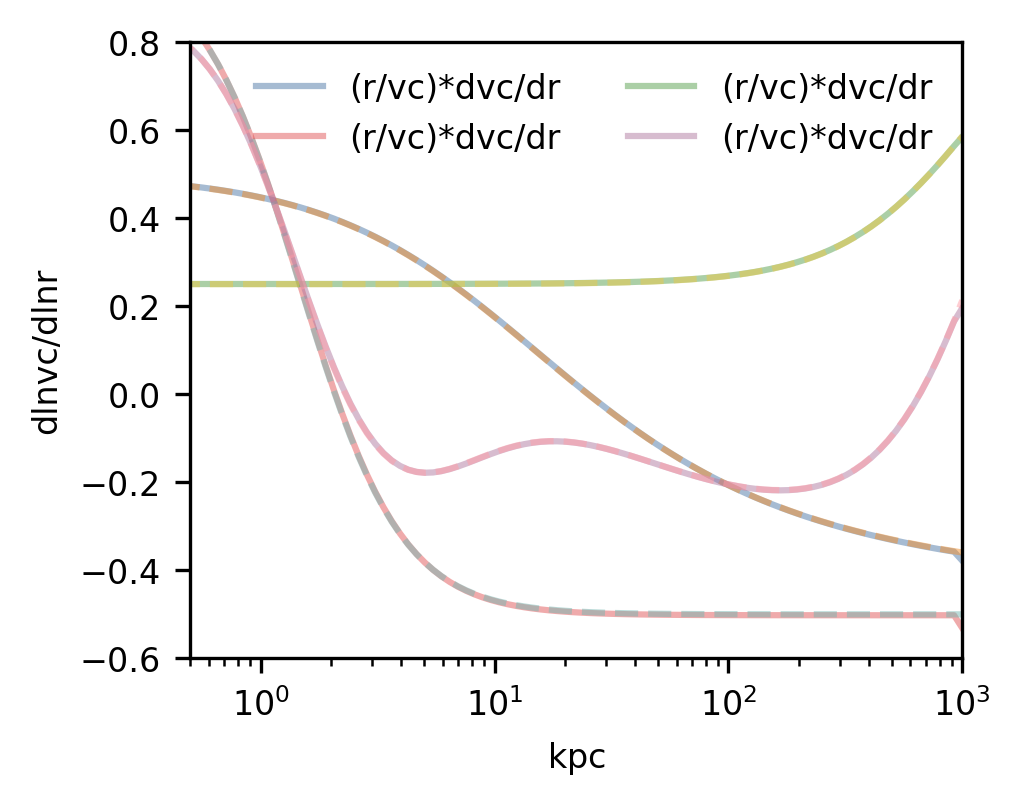

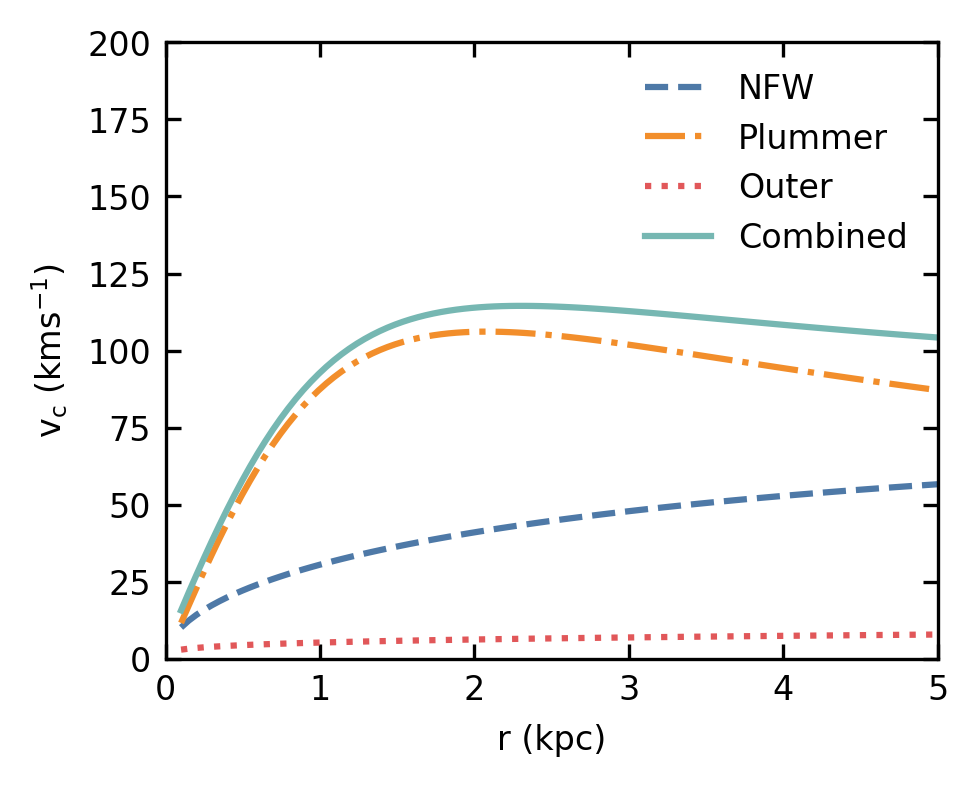

-0.10514452117363872
-0.1051445212235625


In [36]:
# Tests and sanity checks

# Check that dlnvc/dlnr has been implemented correctly 
latexify(columns=1)
plt.figure()

plt.plot(rs,(rs.value/cvs.value)*np.gradient(cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,nfw.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.plot(rs,(rs.value/p_cvs.value)*np.gradient(p_cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,plummer.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.plot(rs,(rs.value/o_cvs.value)*np.gradient(o_cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,outer.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.plot(rs,(rs.value/c_cvs.value)*np.gradient(c_cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,combined.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.ylabel('dlnvc/dlnr')
plt.legend(frameon=False, ncols=2)
plt.xscale('log')
plt.xlim(0.5,1000)
plt.ylim(-0.6,0.8)
plt.show()

# Plot the circular velocity and its components
# This is in the inner region to compare with observed rotation curves in Greco et al 2012 for M82
# The main difference is we are using a R1/2 that is larger by about a factor of 2
rs = np.linspace(0.1,5,100) * un.kpc

cvs = nfw.vc(rs)
p_cvs = plummer.vc(rs)
o_cvs = outer.vc(rs)
c_cvs = combined.vc(rs)

latexify(columns=1)
plt.figure()
ax=plt.gca()
ax.tick_params(top=True, right=True, which="both", direction='in')
plt.xlim(0,5)
plt.ylim(0,200)

plt.plot(rs,cvs,ls='--',label="NFW")
plt.plot(rs,p_cvs,ls='-.',label="Plummer")
plt.plot(rs,o_cvs,ls=':',label="Outer")
plt.plot(rs,c_cvs,ls='-',label="Combined")

plt.xlabel('r (kpc)')
plt.ylabel(r'v$_{\rm c}$ (kms$^{-1}$)')
plt.legend(frameon = False)

plt.show()

# Checking that dphidr calculated two different ways are the same for the combined potential
un_phi = cu_velocity**2

x1l = 125.976562*un.kpc
x2v = 110.351562*un.kpc
x3v = -235.351562*un.kpc

r_ = np.sqrt(x1l**2 + x2v**2 + x3v**2)

vc = combined.vc(r_)
vc_ = (vc/cu_velocity).to('')
dphi_dr = vc_**2/(r_/cu_length).to('')
print(-dphi_dr)

delta_r = 0.00005*un.kpc
phil = combined.Phi(r_ - delta_r)
phir = combined.Phi(r_ + delta_r)
dphi_dr_= (phil-phir)/(2*delta_r)
print((dphi_dr_*cu_length/cu_velocity**2).to(''))

In [8]:
# Set Cooling
cooling = Cool.Wiersma_Cooling(Z2Zsun=1/3,z=0)

In [39]:
# Generate CGM steady-state cooling flow solution
max_step = 0.01                          # lowest resolution of solution in ln(r)
R_min    = 0.1*un.kpc                      # inner radius of supersonic part of solution
R_max    = 230*un.kpc #350                    # outer radius of integration
R_sonic  = 100*un.kpc #0.7*un.kpc #r_gal #12*un.kpc              # sonic radii

print('R_sonic = %s'%R_sonic)
sol = CF.shoot_from_R_sonic(combined,cooling,R_sonic,R_max,R_min,max_step=max_step,verbose=True)
print('Mass Flow Rate: ', sol.mass_flow_rate)

R_sonic = 100.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Starts unbound
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: Unbound (Maximum r = 107 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.750002 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.625004 ... Stop reason: Unbound (Maximum r = 190 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.687503 ... Stop reason: Sonic point (Maximum r = 143 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.656253 ... Stop reason: Sonic point (Maximum r = 185 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.640629 ... Stop reason: Sonic point (Maximum r = 211 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.632816 ... Stop reason: Sonic point (Maximum r = 226 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.628910 ... Stop reason: Unbound (Maximum r = 208 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.630863 ... Stop reason: Unbound (Maximum r = 228 kpc)
Integrating wit

In [27]:
from scipy.integrate import cumulative_trapezoid

def integrate_baryon_mass(Rs, rhos, r_vir):
    """
    Integrate baryon mass from center outward to virial radius.
    
    Parameters:
    -----------
    Rs : array-like
        Radial positions (should be sorted from small to large)
    rhos : array-like
        Baryon densities at each radius
    r_vir : float
        Virial radius
    
    Returns:
    --------
    M_baryon : float
        Total baryon mass within r_vir
    """
    # Rs = np.asarray(Rs)
    # rhos = np.asarray(rhos)
    
    # Only integrate up to r_vir
    mask = Rs <= r_vir
    r_int = Rs[mask]
    rho_int = rhos[mask]
    
    # Mass element: dM = 4π r² ρ dr
    integrand = 4 * np.pi * r_int**2 * rho_int
    
    # Cumulative integration
    M_cumulative = cumulative_trapezoid(integrand, r_int, initial=0)
    
    # Total mass is the final value
    M_baryon = M_cumulative[-1]*integrand.unit*r_int.unit
    
    return M_baryon

# Example usage:
M_b = integrate_baryon_mass(sol.Rs, sol.rhos, r_vir)
print("Total Baryon Mass within R_vir: ", M_b.to('Msun'))
print((M_b/M_vir).to(''))

Total Baryon Mass within R_vir:  2679512143.380908 solMass
0.02679512143380908


In [29]:
# Generate CGM steady-state cooling flow solution
max_step = 0.01                          # lowest resolution of solution in ln(r)
R_min    = 0.1*un.kpc                      # inner radius of supersonic part of solution
R_max    = 350*un.kpc                    # outer radius of integration
R_sonic  = 12*un.kpc #r_gal #12*un.kpc              # sonic radii

print('R_sonic = %s'%R_sonic)
sol = CF.shoot_from_R_sonic(combined,cooling,R_sonic,R_max,R_min,max_step=max_step,verbose=True)
print('Mass Flow Rate: ', sol.mass_flow_rate)

R_sonic = 12.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Unbound (Maximum r = 15 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.250008 ... Stop reason: Unbound (Maximum r = 31 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.375006 ... Stop reason: Unbound (Maximum r = 57 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.437506 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.406256 ... Stop reason: Unbound (Maximum r = 113 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.421881 ... Stop reason: Sonic point (Maximum r = 93 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.414068 ... Stop reason: Sonic point (Maximum r = 239 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.410162 ... Stop reason: Unbound (Maximum r = 188 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.412115 ... Stop reason: Sonic point (Maximum r = 306 kpc)
Integrating wit

In [ ]:
combined2 = Halo.CombinedPotential_using_modified_plummer(M_vir, r_vir, c_vir, M_gal, z_gal, r_gal, rho_mean, r_200_m)

# Generate CGM steady-state cooling flow solution
max_step = 0.01                          # lowest resolution of solution in ln(r)
R_min    = 0.1*un.kpc                      # inner radius of supersonic part of solution
R_max    = 350*un.kpc                    # outer radius of integration
R_sonic  = 1.6*un.kpc              # sonic radii

print('R_sonic = %s'%R_sonic)
sol2 = CF.shoot_from_R_sonic(combined2,cooling,R_sonic,R_max,R_min,max_step=max_step,verbose=True)
print('Mass Flow Rate: ', sol2.mass_flow_rate)

R_sonic = 1.6 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Unbound (Maximum r = 5 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.250008 ... Stop reason: Sonic point (Maximum r = 45 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.125009 ... Stop reason: Unbound (Maximum r = 11 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.187508 ... Stop reason: Unbound (Maximum r = 23 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.218758 ... Stop reason: Unbound (Maximum r = 44 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.234383 ... Stop reason: Unbound (Maximum r = 99 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.242195 ... Stop reason: Sonic point (Maximum r = 124 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.238289 ... Stop reason: Sonic point (Maximum r = 278 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.236336 ... Stop reason: Max R reached (Maximum r = 349 kpc)
Inward 

In [20]:
# Save file

"""
The file format is a header line followed by data columns:
# r T rho v
r_1 T_1 rho_1 v_1
r_2 T_2 rho_2 v_2
"""

Rs = (sol2.Rs/cu_length).to('').value
Ts = (sol2.Ts/cu_temperature).to('').value
rhos = (sol2.rhos/cu_density).to('').value
vs = (sol2.vs/cu_velocity).to('').value

# Combine arrays into a single array for saving
data = np.column_stack((Rs, Ts, rhos, vs))

# Save to file with header
header = "# r T rho v"
filename = "tables/cgm_profiles_rsonic_1.6_vertical.txt"
np.savetxt(filename, data, header=header)

print(f"Profile saved to {filename}")

Profile saved to tables/cgm_profiles_rsonic_1.6_vertical.txt


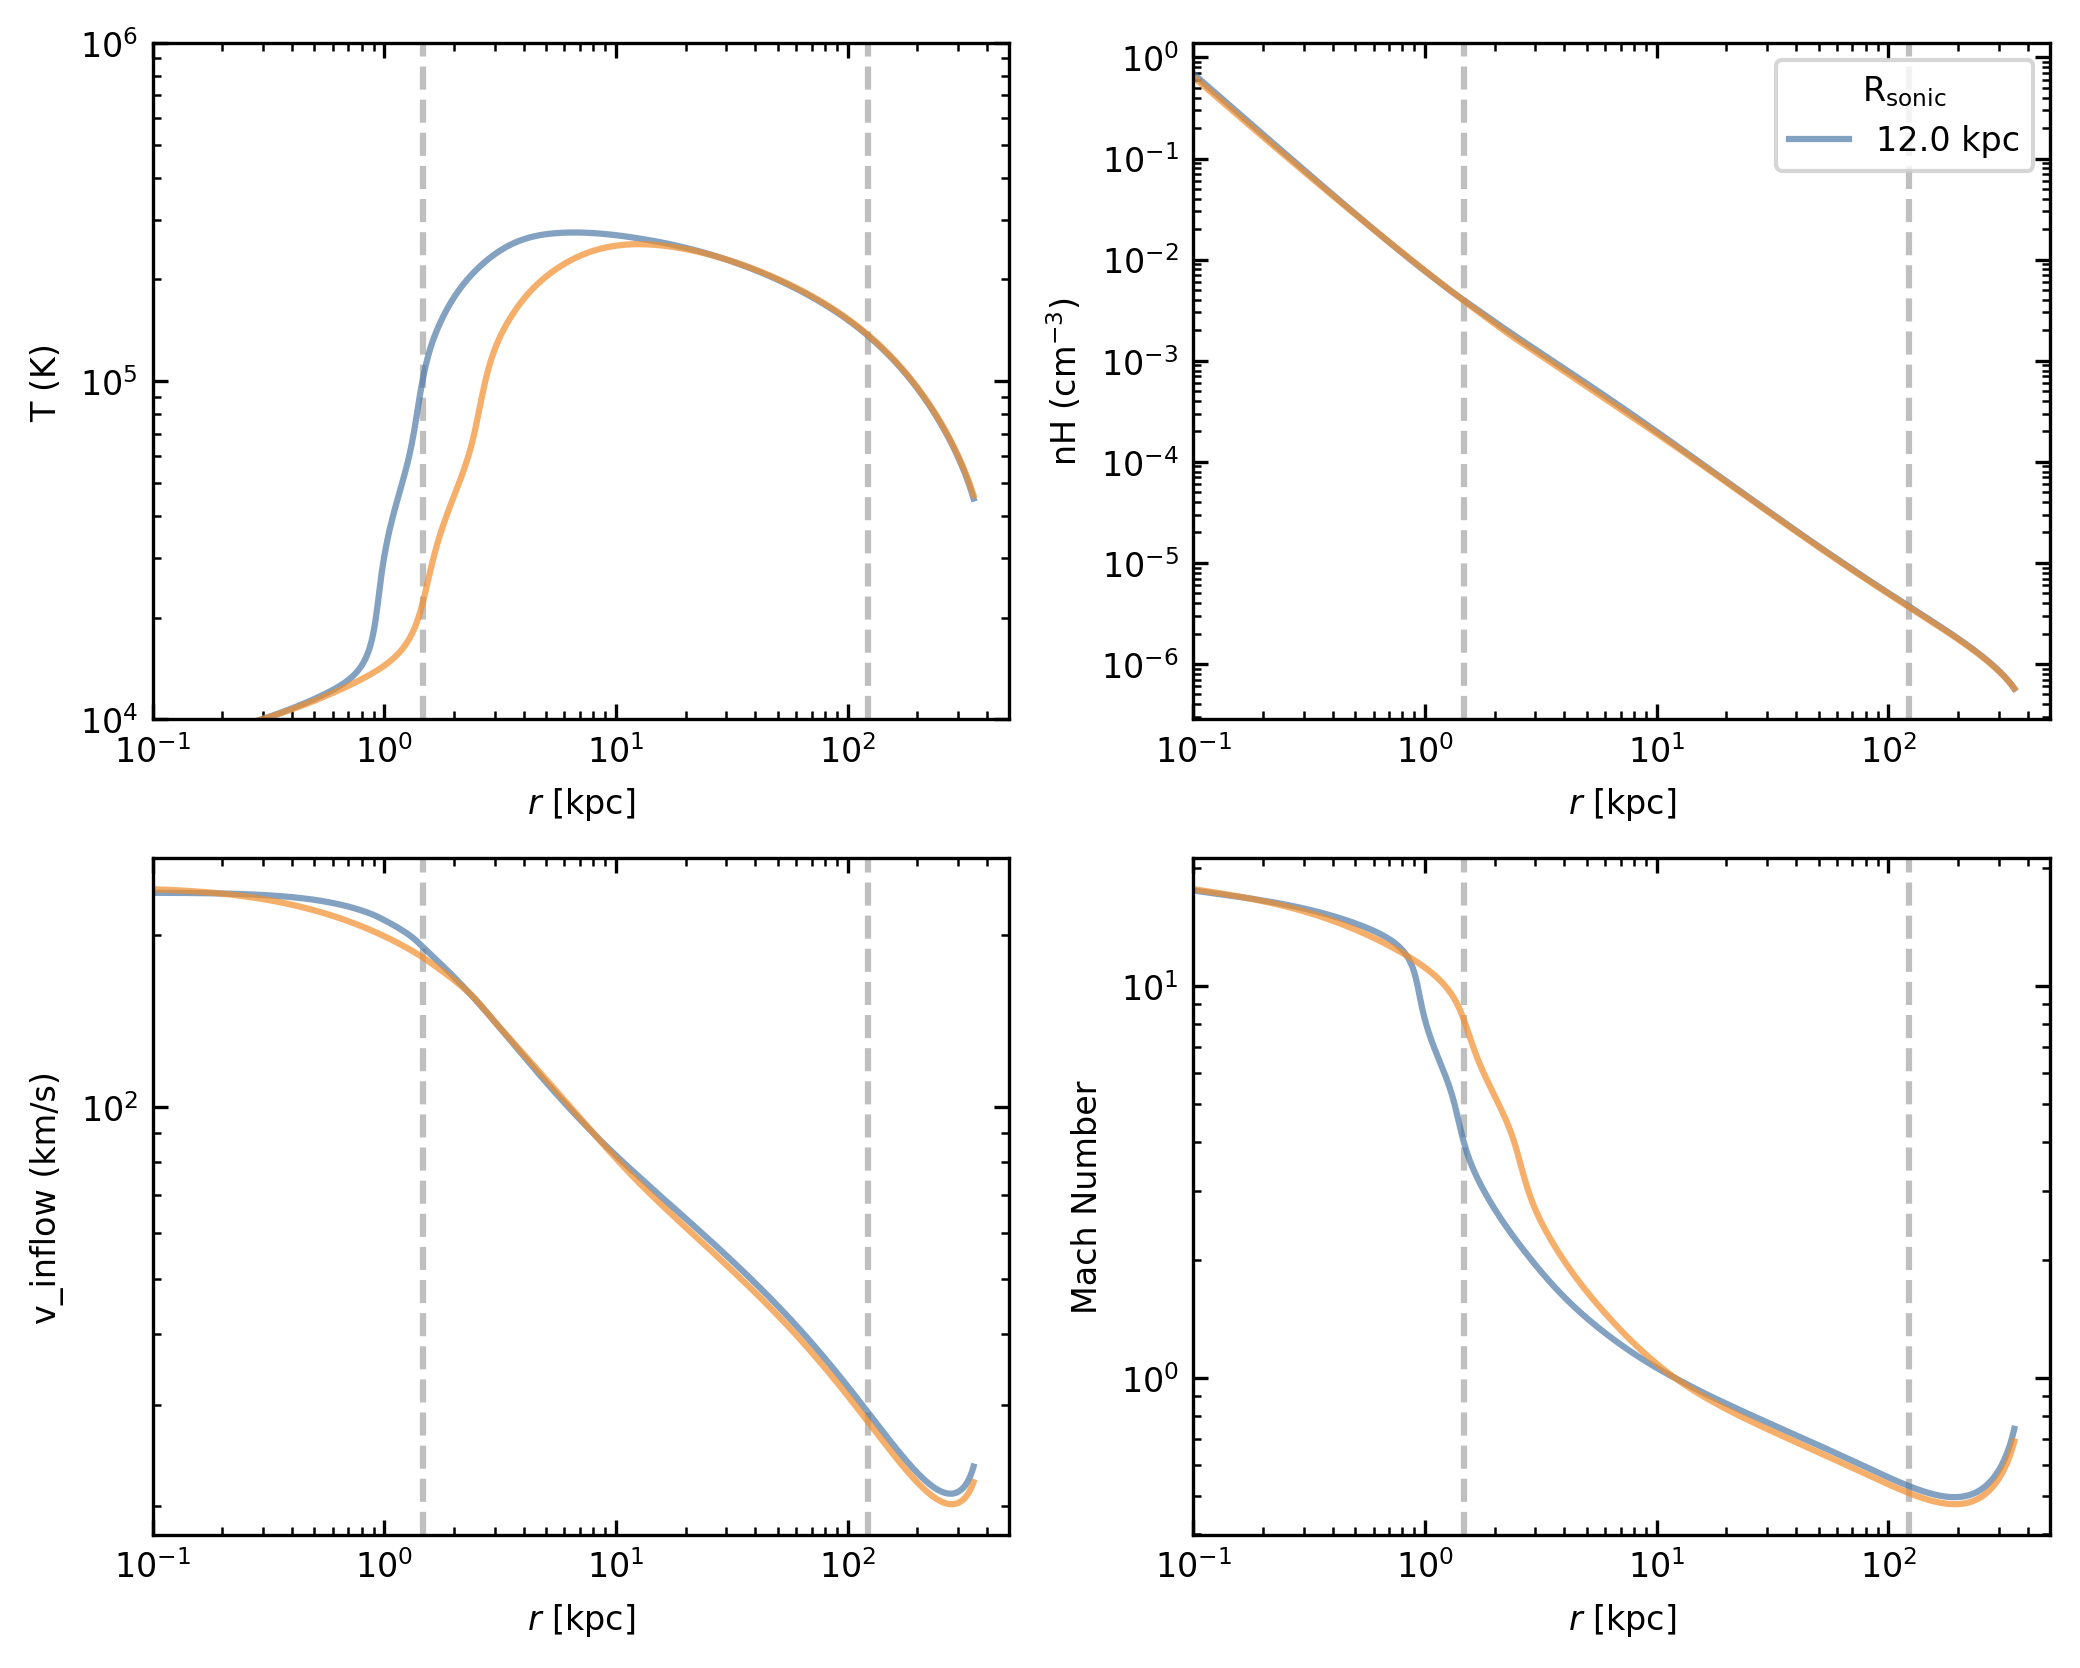

In [ ]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'$r$ [kpc]')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(.1,500)

    ax.axvline(r_gal,c='.5',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='.5',ls='--',alpha=0.5)

axs[0, 0].plot(sol.Rs, sol.Ts, alpha=0.7)
axs[0, 0].plot(sol2.Rs, sol2.Ts, alpha=0.7)
axs[0, 0].set_ylabel(r'T (K)')
axs[0, 0].set_ylim(1e4,1e6)

axs[0, 1].plot(sol.Rs, sol.nHs, alpha=0.7, label=f'{sol.R_sonic:.1f}')
axs[0, 1].plot(sol2.Rs, sol2.nHs, alpha=0.7)
axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')

axs[1, 0].plot(sol.Rs, sol.vs, alpha=0.7)
axs[1, 0].plot(sol2.Rs, sol2.vs, alpha=0.7)
axs[1, 0].set_ylabel(r'v_inflow (km/s)')
    
axs[1, 1].plot(sol.Rs, sol.Ms, alpha=0.7)
axs[1, 1].plot(sol2.Rs, sol2.Ms, alpha=0.7)
axs[1, 1].set_ylabel(r'Mach Number')

axs[0, 1].legend(frameon=True, loc='upper right', title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
plt.show()

In [9]:
## Compute rho(r) for the galactic disk
import scipy.integrate 

# Compute surface density profile
M_gas = 2.5e9 * un.Msun # Greco et al 2012 for M82
Sigma_0 = M_gas/(2*np.pi*r_gal**2)
T_disk = 1e4 * un.K # Temperature of isothermal disk

def phi_total(R,z):
    return miyamoto.Phi(R,z).to('km^2/s^2')

def midplane_density(R):
    sigma = Sigma_0*np.exp(-R/r_gal)
    phi0 = phi_total(R, 0*un.kpc)
    # Numerically integrate the density at R over all z
    def f(z):
        z = z*un.kpc
        phi = phi_total(R,z)
        cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2') # use the isothermal and not adiabatic sound speed
        return np.exp((-(phi-phi0)/cs2).to('').value)
    zlim = 10*(z_gal/un.kpc).to('')
    integral = scipy.integrate.quad(f,-zlim,zlim) # integrate vertically over 10 scale heights
    return sigma/integral[0]/(1.0 * un.kpc)

disk_Rs = np.logspace(-3,np.log10(20),100) * un.kpc
midplane_rhos = [midplane_density(r) for r in disk_Rs]

rho0 = midplane_rhos[0]
def f(z):
    phi0 = phi_total(0*un.kpc,0*un.kpc)
    phi = phi_total(0*un.kpc,z)
    cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2')
    return np.exp((-(phi-phi0)/cs2).to(''))
center_rhos = rho0*f(disk_Rs)

def rho_to_n(rhos):
    return np.array([(rho/mu/cons.m_p).to('cm**-3').value for rho in rhos])*un.cm**-3

midplane_ns = rho_to_n(midplane_rhos)
center_ns = rho_to_n(center_rhos)

In [10]:
print((rho0/cu_density).to('')) # for initializing dedt in turbulent driving

1346.736770404842


In [11]:
rho1 = midplane_rhos[80]
print(disk_Rs[80])
def f1(z):
    phi0 = phi_total(disk_Rs[80],0*un.kpc)
    phi = phi_total(disk_Rs[80],z)
    cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2')
    return np.exp((-(phi-phi0)/cs2).to(''))
center_rhos_1 = rho1*f1(disk_Rs)
center_ns_1 = rho_to_n(center_rhos_1)

2.989370844284541 kpc


In [12]:
rho2 = midplane_rhos[73]
print(disk_Rs[73])
def f2(z):
    phi0 = phi_total(disk_Rs[73],0*un.kpc)
    phi = phi_total(disk_Rs[73],z)
    cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2')
    return np.exp((-(phi-phi0)/cs2).to(''))
center_rhos_2 = rho2*f2(disk_Rs)
center_ns_2 = rho_to_n(center_rhos_2)

1.4841116097828666 kpc


In [13]:
h_scale_radius = 0.64 * r_gal
h_scale_height = 0.33 * z_gal # 0.33

fit_norm_rho = midplane_density(0*un.kpc)
fit_norm = rho_to_n([fit_norm_rho])[0]
fit_ns_1 = np.array([fit_norm.value*np.exp(-r/h_scale_radius) for r in disk_Rs])

# h_scale_alpha = 0.002 
# fit_ns_2 = np.array([fit_ns_1[0]* np.exp(-r**2/(h_scale_height**2 +  h_scale_alpha*disk_Rs[0]**2)) for r in disk_Rs])
# fit_ns_3 = np.array([fit_ns_1[80]*np.exp(-r**2/(h_scale_height**2 + h_scale_alpha*disk_Rs[80]**2)) for r in disk_Rs])
# fit_ns_4 = np.array([fit_ns_1[73]*np.exp(-r**2/(h_scale_height**2 + h_scale_alpha*disk_Rs[73]**2)) for r in disk_Rs])

# h_scale_alpha = 1
fit_ns_2 = np.array([fit_ns_1[0]* np.exp(-r**2/(h_scale_height**2 * ( 1 + np.power(disk_Rs[ 0]/h_scale_radius,2)))) for r in disk_Rs])
fit_ns_3 = np.array([fit_ns_1[80]*np.exp(-r**2/(h_scale_height**2 * ( 1 + np.power(disk_Rs[80]/h_scale_radius,2)))) for r in disk_Rs])
fit_ns_4 = np.array([fit_ns_1[73]*np.exp(-r**2/(h_scale_height**2 * ( 1 + np.power(disk_Rs[73]/h_scale_radius,2)))) for r in disk_Rs])

# Print in Physical Units
print("Physical Units:")
print("Normalization: ", fit_norm)
print("Heating Scale Radius: ", h_scale_radius)
print("Heating Scale Height: ", h_scale_height)
print(" ")

# Print in Code Units
print("Code Units:")
print("hscale_norm   =", (fit_norm_rho/cu_density).to(''))
print("hscale_radius =", (h_scale_radius/cu_length).to(''))
print("hscale_height =", (h_scale_height/cu_length).to(''))
# print("hscale_alpha  =", h_scale_alpha)

Physical Units:
Normalization:  134.33069091273904 1 / cm3
Heating Scale Radius:  0.9402361258281289 kpc
Heating Scale Height:  0.0495 kpc
 
Code Units:
hscale_norm   = 1347.6541799847946
hscale_radius = 0.9402361259893334
hscale_height = 0.04950000000848683


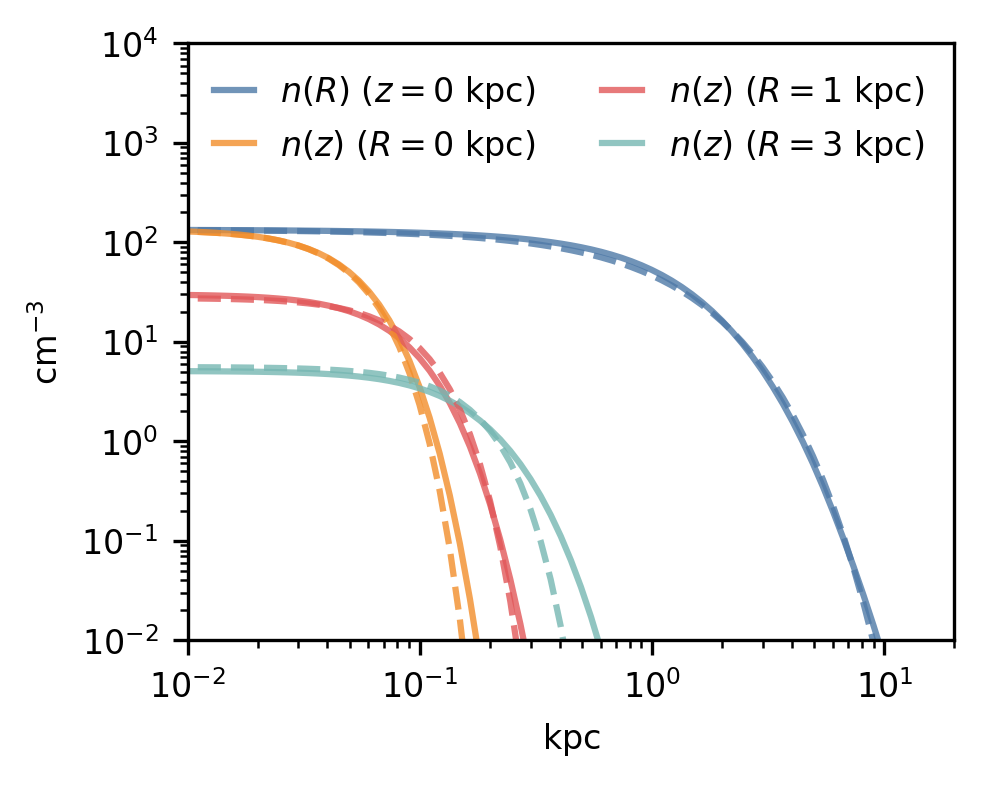

In [14]:
latexify(columns=1)
plt.figure()
plt.plot(disk_Rs, midplane_ns, alpha=0.8, label=r'$n(R)$ ($z=0$ kpc)')
plt.plot(disk_Rs, center_ns,   alpha=0.8, label=r'$n(z)$ ($R=0$ kpc)')
plt.plot(disk_Rs, center_ns_2, alpha=0.8, label=r'$n(z)$ ($R=1$ kpc)')
plt.plot(disk_Rs, center_ns_1, alpha=0.8, label=r'$n(z)$ ($R=3$ kpc)')

plt.plot(disk_Rs, fit_ns_1, ls='--', alpha=0.8, c='C0')
plt.plot(disk_Rs, fit_ns_2, ls='--', alpha=0.8, c='C1')
plt.plot(disk_Rs, fit_ns_4, ls='--', alpha=0.8, c='C2')
plt.plot(disk_Rs, fit_ns_3, ls='--', alpha=0.8, c='C3')

# plot a guassian for reference
y_turb = 0.75 * un.kpc  # 1/3 galaxy scale radius
z_turb = 0.03 * un.kpc # 1/5 galaxy scale height
y_gaussian_ns = midplane_ns[0] * np.exp(-0.5*(disk_Rs/y_turb)**2)
z_gaussian_ns = midplane_ns[0] * np.exp(-0.5*(disk_Rs/z_turb)**2)
# plt.plot(disk_Rs, y_gaussian_ns, ls=':', alpha=0.8, c='k') 
# plt.plot(disk_Rs, z_gaussian_ns, ls=':', alpha=0.8, c='k')

plt.loglog()
plt.ylim(1e-2,1e4)
plt.xlim(1e-2,20)
plt.legend(loc = 'upper right', ncols=2, frameon=False, handlelength=1.2)
plt.tight_layout()
# plt.savefig('plots/density_profiles.pdf',dpi=300)
plt.show()

In [74]:
# Save file
Rs = (disk_Rs/cu_length).to('').value
Ts = np.array([(T_disk/cu_temperature).to('').value for _ in disk_Rs])
rhos = np.array([(m/cu_density).to('').value for m in midplane_rhos])
vs = np.array([0. for _ in disk_Rs])

"""
The file format is a header line followed by data columns:
# r T rho v
r_1 T_1 rho_1 v_1
r_2 T_2 rho_2 v_2
"""

# Combine arrays into a single array for saving
data = np.column_stack((Rs, Ts, rhos, vs))

# Save to file with header
header = "# r T rho v"
filename = "disk_profiles.txt"
np.savetxt(filename, data, header=header)

print(f"Profiles saved to {filename}")

Profiles saved to disk_profiles.txt
